In [11]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

## Statistical Difference of the SVC Model

In [3]:
#import stats from ica model performance
matched = np.load('matched_data_SVC.npy')

In [4]:
#import stats from ca model performance
hem = np.load('hemisphere_data.npy')

(array([  5.,   7.,   9.,   1.,   0.,   0.,   0.,   0.,   0., 478.]),
 array([0.98333333, 0.985     , 0.98666667, 0.98833333, 0.99      ,
        0.99166667, 0.99333333, 0.995     , 0.99666667, 0.99833333,
        1.        ]),
 <BarContainer object of 10 artists>)

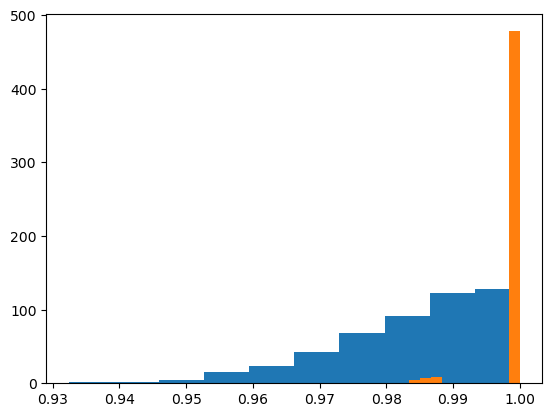

In [16]:
plt.hist(matched)
plt.hist(hem)

In [18]:
stat, p_value = stats.wilcoxon(matched, hem)

alpha=0.05
if p_value < alpha:
    print("Significant difference between ICA and Hemisphere parcellation performance.")
else:
    print("No significant difference between ICA and Hemisphere parcellation performance.")


Significant difference between ICA and Hemisphere parcellation performance.


In [20]:
import numpy as np

def bootstrap_ci(data1, data2, n_bootstrap=10000, confidence=0.95):
    """Computes bootstrap confidence intervals for the difference in means"""
    boot_diffs = []
    np.random.seed(42)  # For reproducibility

    for _ in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=len(data1), replace=True)
        sample2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(sample2) - np.mean(sample1))  # Difference in means

    lower = np.percentile(boot_diffs, (1 - confidence) / 2 * 100)
    upper = np.percentile(boot_diffs, (1 + confidence) / 2 * 100)
    
    return lower, upper

# Compute 95% confidence interval for difference in performance
ci_lower, ci_upper = bootstrap_ci(matched, hem)

print(f"95% Bootstrapped Confidence Interval for the difference: ({ci_lower:.4f}, {ci_upper:.4f})")

if ci_lower < 0 and ci_upper > 0:
    print(f"0 is within our confidence interval and thus the difference between models is not significant")
else:
    print(f"0 is NOT within our confidence interval and thus the difference between models IS significant")

95% Bootstrapped Confidence Interval for the difference: (0.0142, 0.0165)
0 is NOT within our confidence interval and thus the difference between models IS significant
